# Credit Risk Prediction Using Machine Learning



## 1. Project Objective

Banks and financial institutions face the challenge of determining whether a loan applicant is likely to repay or default on a loan.

The objective of this project is to build a machine learning model that predicts whether a customer represents a good or bad credit risk using the German Credit dataset.

The insights from this model can help financial institutions:

- Reduce loan defaults
- Improve lending decisions
- Minimize financial losses
- Support responsible lending

In [1]:
# ==========================================================
# Credit Risk Prediction Project
# Notebook 1: Data Understanding
# Author: Victor Ojwang
# ==========================================================

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Loading

In [3]:
#load dataset
df = pd.read_csv("german_credit_data.csv")
#display the first  five  rows
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


## 3. Data Understanding

In [4]:
# Dataset dimensions
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 11)


In [5]:
# Display column names
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [6]:
# Check data types
df.dtypes

,0
Unnamed: 0,int64
Age,int64
Sex,object
Job,int64
Housing,object
Saving accounts,object
Checking account,object
Credit amount,int64
Duration,int64
Purpose,object


In [7]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [8]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [9]:
df.tail()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad
999,999,27,male,2,own,moderate,moderate,4576,45,car,good


In [10]:
#random  sampling
df.sample(10)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
548,548,24,female,1,own,little,little,626,12,radio/TV,bad
280,280,23,male,2,rent,rich,NaN,3368,15,car,good
302,302,37,male,1,own,NaN,rich,1344,24,car,bad
306,306,24,female,1,rent,NaN,NaN,4811,30,car,good
364,364,25,male,0,own,little,little,2473,18,furniture/equipment,bad
894,894,29,male,2,own,NaN,NaN,1169,18,radio/TV,good
756,756,74,male,0,own,little,rich,1299,6,car,good
835,835,48,male,2,own,little,little,1082,12,car,bad
141,141,30,female,3,own,little,moderate,4795,36,radio/TV,good
420,420,20,female,2,rent,rich,NaN,3186,15,car,good


In [11]:
#Summary Statistics
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [12]:
# Missing values
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [13]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

In [14]:
# Check class distribution
df["Risk"].value_counts()

,count
Risk,
good,700
bad,300


In [15]:
# Check class percentages
df["Risk"].value_counts(normalize=True) * 100

,proportion
Risk,
good,70.0
bad,30.0


## 4. Data Cleaning

In [16]:
# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Verify the column was removed
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [17]:
# Save cleaned dataset
df.to_csv("german_credit_clean.csv", index=False)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!




## Dataset Overview

The German Credit dataset contains information on **1,000 loan applicants** and **11 variables**. Each record represents a customer applying for credit, while each feature describes demographic, financial, or loan-related characteristics that may influence the customer's credit risk.

## Dataset Summary

- Total observations: **1,000**
- Total variables: **11**
- Numerical features: **5**
- Categorical features: **6**
- Target variable: **Risk**
- Missing values:
  - Saving accounts: **183**
  - Checking account: **394**
- Unnecessary column:
  - **Unnamed: 0** (index column)

## Initial Observations

- The dataset contains both numerical and categorical variables.
- The target variable **Risk** classifies customers as either **Good** or **Bad** credit risk.
- Two variables contain missing values and will require preprocessing before model training.
- The **Unnamed: 0** column is an index column and does not contribute to prediction, so it will be removed.
- Credit amounts range from **250** to **18,424**, indicating potential outliers that will be explored during Exploratory Data Analysis (EDA).
- Customer ages range from **19** to **75** years, with an average age of approximately **36** years.
- Loan durations range from **4** to **72** months, with an average duration of approximately **21** months.

## Business Objective

The objective of this project is to build a machine learning model that predicts whether a loan applicant represents a **Good** or **Bad** credit risk based on demographic, financial, and loan-related characteristics.

The model can help financial institutions:

- Improve credit approval decisions.
- Reduce loan defaults.
- Minimize financial losses.
- Support data-driven lending strategies.

## Data Preparation Plan

Before building the machine learning model, the following preprocessing steps will be performed:

1. Remove the **Unnamed: 0** index column.
2. Handle missing values in **Saving accounts** and **Checking account**.
3. Encode categorical variables into numerical format.
4. Explore feature distributions and relationships through Exploratory Data Analysis (EDA).
5. Prepare the dataset for machine learning model development.

## Data Management

To ensure reproducibility and maintain data integrity:

- The **raw dataset** will remain unchanged throughout the project.
- A **cleaned version** of the dataset will be created after preprocessing.
- All subsequent analysis and machine learning models will use the cleaned dataset.

## 5. Exploratory Data Analysis (EDA)

### 5.1 Univariate Analysis

**Section 1: Import Visualization Libraries**

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("ggplot")

print("Visualization libraries loaded successfully!")

Visualization libraries loaded successfully!


**Section 2: Check the Target Variable**

In [19]:
# Count customers in each risk category
df["Risk"].value_counts()

,count
Risk,
good,700
bad,300


Lets visualized it on  a chart

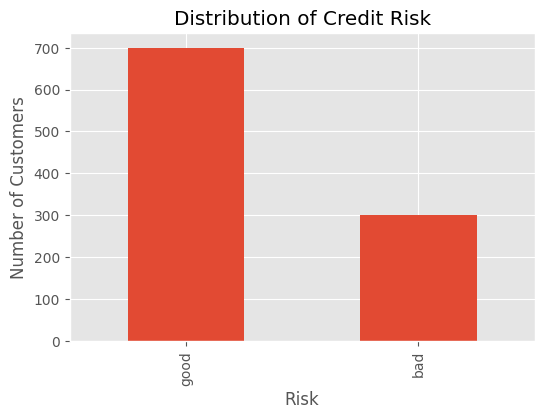

In [20]:
risk_counts = df["Risk"].value_counts()

plt.figure(figsize=(6,4))
risk_counts.plot(kind="bar")

plt.title("Distribution of Credit Risk")
plt.xlabel("Risk")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The target variable **Risk** consists of two classes:

- **Good credit risk:** 700 customers (70%)
- **Bad credit risk:** 300 customers (30%)

This indicates that the dataset is **imbalanced**, with a higher proportion of good credit customers than bad credit customers.

### Business Interpretation

This class imbalance is common in real-world lending data because most borrowers successfully repay their loans. During model evaluation, relying solely on **accuracy** may produce misleading results. Therefore, additional evaluation metrics such as **Precision, Recall, F1-score, and ROC-AUC** will be used to assess the model's performance, particularly its ability to correctly identify high-risk customers.

**Section 3: Age Distribution**

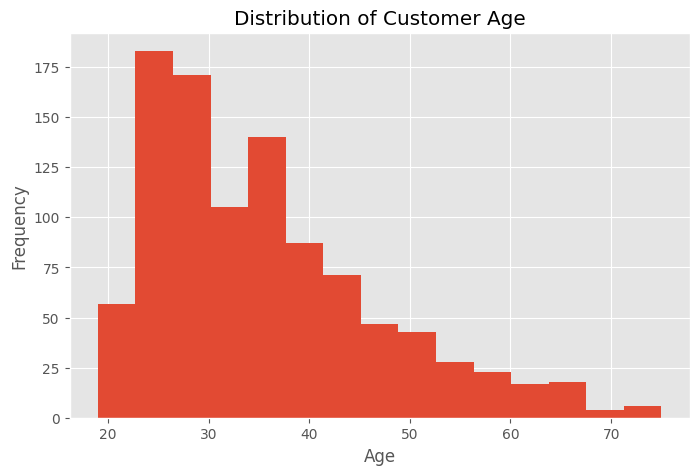

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=15)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Key Findings

- Customer ages range from **19 to 75 years**.
- Most loan applicants are between **25 and 40 years** old.
- The age distribution is **right-skewed**, with fewer applicants in the older age groups (above 55 years).

### Business Interpretation

The bank's lending portfolio is concentrated among young and middle-aged adults, who represent the largest group of loan applicants. This suggests that lending products are primarily serving individuals in their economically active years.

The relationship between **Age** and **Risk** will be explored later to determine whether younger or older customers are more likely to be classified as **Good** or **Bad** credit risks.

**Section 4: Credit Amount Distribution**

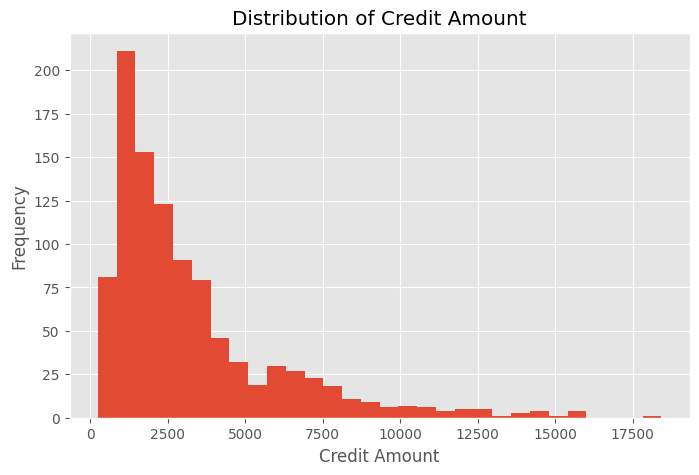

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df["Credit amount"], bins=30)

plt.title("Distribution of Credit Amount")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")

plt.show()

### Key Findings

- Credit amounts range from **250** to **18,424** monetary units.
- Most customers borrow relatively small loan amounts, generally below **5,000**.
- The distribution is **positively (right) skewed**, with a small number of customers requesting substantially larger loans.
- A few high-value loans appear to be potential outliers and will be investigated further during the analysis.

### Business Interpretation

The bank's loan portfolio is dominated by small- to medium-sized loans, while relatively few customers request very large amounts. Larger loans expose financial institutions to greater potential losses if a borrower defaults.

Further analysis will examine whether customers requesting larger loan amounts are more likely to be classified as **Bad** credit risks. If a relationship exists, **Credit amount** could become an important predictor in the machine learning model.

**Section 5: Loan Duration Distribution**

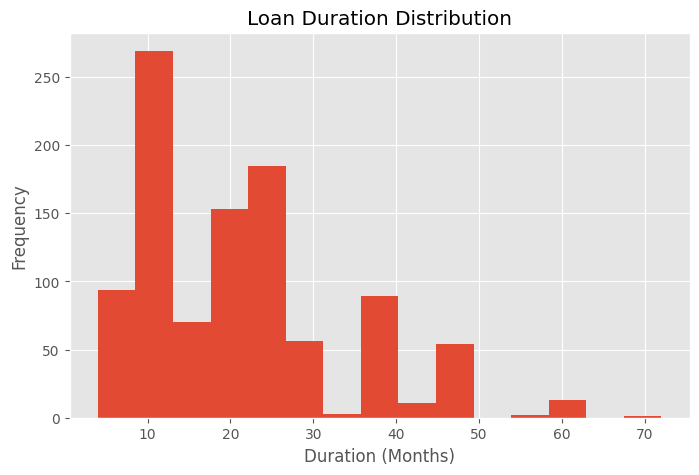

In [23]:
plt.figure(figsize=(8,5))

plt.hist(df["Duration"], bins=15)

plt.title("Loan Duration Distribution")
plt.xlabel("Duration (Months)")
plt.ylabel("Frequency")

plt.show()

### Key Findings

- Loan durations range from **4 to 72 months**.
- Most loans have repayment periods between **12 and 24 months**.
- The distribution is **right-skewed**, with relatively few customers taking loans longer than **48 months**.
- A small number of customers have long-term loans extending up to **72 months**.

### Business Interpretation

Most customers prefer short- to medium-term loans, indicating that the bank's lending portfolio is concentrated in relatively shorter repayment periods.

Longer loan durations increase the period during which economic conditions and customer financial circumstances can change, potentially increasing the probability of default.

In the next stage of the analysis, we will investigate whether customers with longer loan durations are more likely to be classified as **Bad** credit risks. If a relationship exists, **Duration** is likely to be an important predictor in the machine learning model.

**Section 6: Gender Distribution**

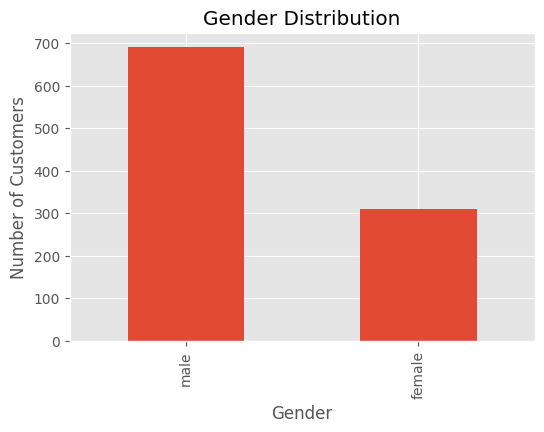

In [24]:
gender = df["Sex"].value_counts()

plt.figure(figsize=(6,4))

gender.plot(kind="bar")

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Number of Customers")

plt.show()

### Key Findings

- The dataset contains approximately **690 male applicants (69%)** and **310 female applicants (31%)**.
- Male customers represent more than two-thirds of the loan applicants in the dataset.
- The lending portfolio is therefore dominated by male borrowers.

### Business Interpretation

The higher proportion of male applicants suggests that the institution historically received more loan applications from men than women. However, this distribution alone does **not** indicate that one gender is more or less risky than the other.

In the next stage of the analysis, we will compare **Gender** with the **Risk** variable to determine whether there is any relationship between gender and credit risk. Any conclusions about risk should be based on the target variable rather than applicant counts alone.

**Section 7: Housing Type**

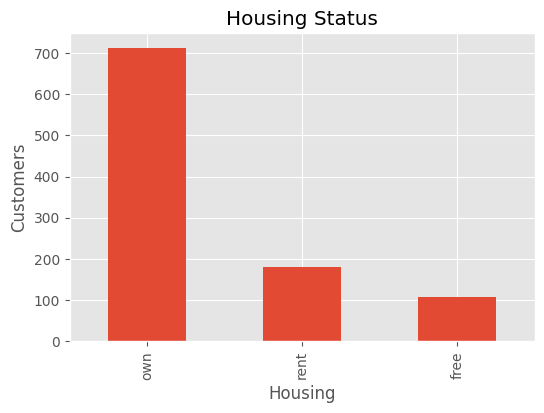

In [25]:
housing = df["Housing"].value_counts()

plt.figure(figsize=(6,4))

housing.plot(kind="bar")

plt.title("Housing Status")

plt.xlabel("Housing")

plt.ylabel("Customers")

plt.show()

### Key Findings

- The majority of customers (**approximately 71%**) own their homes.
- Around **18%** of customers live in rented accommodation.
- Approximately **11%** of customers live in free accommodation.
- Homeowners represent the largest segment of the bank's lending portfolio.

### Business Interpretation

Housing status is an important customer characteristic because it may reflect financial stability and long-term economic circumstances. However, this chart only shows the distribution of customers across housing categories and does not indicate whether one housing group has a higher or lower credit risk.

In the next stage of the analysis, we will compare **Housing** with the **Risk** variable to determine whether housing status is associated with good or bad credit risk.

**Section 8: Loan Purpose**

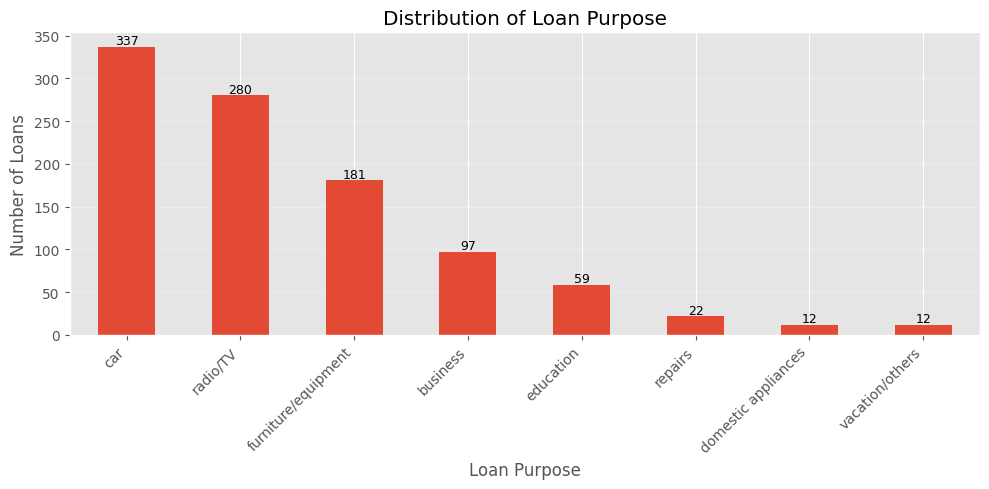

In [26]:
purpose = df["Purpose"].value_counts()

plt.figure(figsize=(10,5))

ax = purpose.plot(kind="bar")

plt.title("Distribution of Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Number of Loans")

# Rotate labels
plt.xticks(rotation=45, ha='right')

# Add values on bars
for i, value in enumerate(purpose):
    ax.text(i, value + 3, str(value), ha='center', fontsize=9)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

### Key Findings

- **Car** is the most common reason for applying for credit, accounting for the highest number of loans.
- **Radio/TV** is the second most common loan purpose.
- **Furniture/Equipment** also represents a significant portion of the lending portfolio.
- Business, education, repairs, domestic appliances, and vacation/other account for a much smaller proportion of loan applications.
- The distribution of loan purposes is uneven, with most loans concentrated in a few categories.

### Business Interpretation

The lending portfolio is primarily driven by consumer-related borrowing, particularly for purchasing vehicles and household goods. This information can help financial institutions understand customer borrowing behavior and tailor lending products to meet the most common financing needs.

However, the frequency of a loan purpose does not necessarily indicate its level of credit risk. In the next stage of the analysis, we will compare **Purpose** with the **Risk** variable to identify whether certain loan purposes are associated with a higher proportion of bad credit risk.

### 5.2 Bivariate Analysis

**Chart 1: Risk by Gender**

In [27]:
# Risk by Gender
gender_risk = pd.crosstab(df["Sex"],
                          df["Risk"],
                          normalize="index")*100

gender_risk

Risk,bad,good
Sex,,
female,35.161290,64.838710
male,27.681159,72.318841


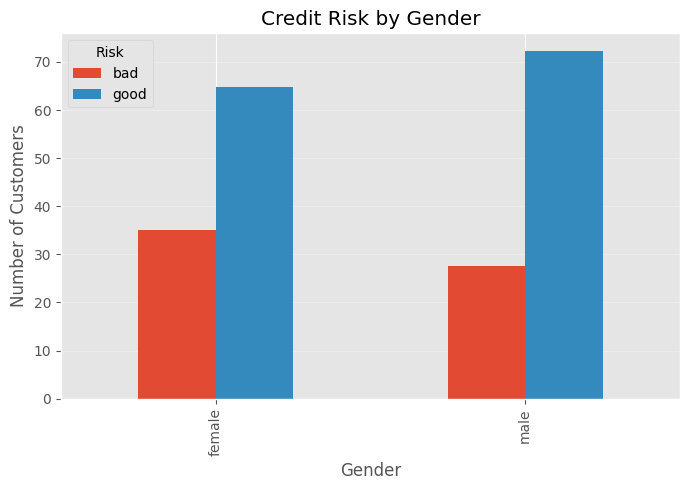

In [28]:
gender_risk.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Credit Risk by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

### Key Findings

- Among female applicants, **35.16%** were classified as **Bad** credit risks, while **64.84%** were classified as **Good** credit risks.
- Among male applicants, **27.68%** were classified as **Bad** credit risks, while **72.32%** were classified as **Good** credit risks.
- Female applicants have a higher proportion of bad credit risk compared to male applicants in this dataset.

### Business Interpretation

The analysis suggests that female applicants in this dataset have a higher percentage of bad credit risk than male applicants. However, this observation is based solely on the historical data provided and should **not** be interpreted as evidence that gender causes credit risk.

In practice, financial institutions should evaluate creditworthiness using multiple financial and behavioral characteristics rather than relying on a single demographic variable. During model development, we will assess the importance of **Gender** alongside other predictors such as loan amount, duration, housing status, and account information.

**Chart 2: Risk by Housing**

In [29]:
housing_risk = pd.crosstab(df["Housing"],
                           df["Risk"],
                           normalize="index")*100
housing_risk

Risk,bad,good
Housing,,
free,40.740741,59.259259
own,26.086957,73.913043
rent,39.106145,60.893855


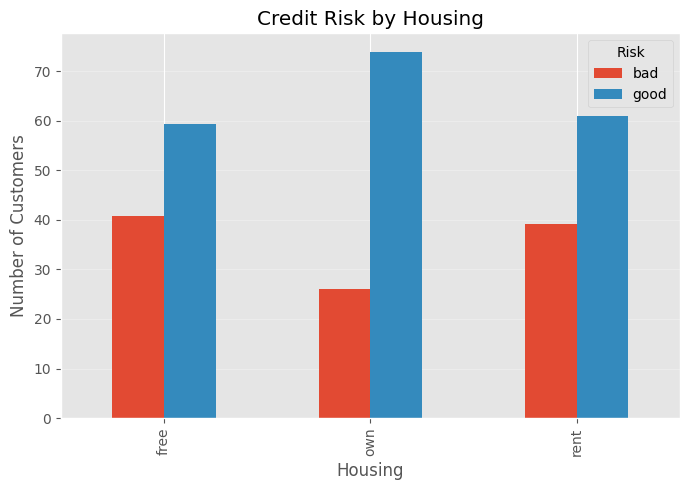

In [30]:
housing_risk.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Credit Risk by Housing")
plt.xlabel("Housing")
plt.ylabel("Number of Customers")

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

### Key Findings

- Customers who **own** their homes have the lowest proportion of **Bad** credit risk (**26.09%**) and the highest proportion of **Good** credit risk (**73.91%**).
- Customers living in **free accommodation** have the highest proportion of **Bad** credit risk (**40.74%**).
- Customers who **rent** also have a relatively high proportion of **Bad** credit risk (**39.11%**).
- Homeowners appear to have better credit outcomes than customers who rent or live in free accommodation.

### Business Interpretation

Housing status appears to be an important factor associated with credit risk in this dataset. Customers who own their homes are more likely to be classified as **Good** credit risks, while customers renting or living in free accommodation have higher proportions of **Bad** credit risk.

This relationship may reflect differences in financial stability or long-term economic circumstances. However, housing status alone should not determine lending decisions. It should be evaluated together with other applicant characteristics such as income, loan amount, repayment duration, and account history.

The results suggest that **Housing** may be a valuable feature for the machine learning model and will be retained during model development.

**Chart 3: Risk by Purpose**

In [31]:
purpose_risk = pd.crosstab(df["Purpose"],
                           df["Risk"],
                           normalize="index")*100

purpose_risk

Risk,bad,good
Purpose,,
business,35.051546,64.948454
car,31.454006,68.545994
domestic appliances,33.333333,66.666667
education,38.983051,61.016949
furniture/equipment,32.044199,67.955801
radio/TV,22.142857,77.857143
repairs,36.363636,63.636364
vacation/others,41.666667,58.333333


### Key Findings

- Customers borrowing for **Radio/TV** purchases have the **lowest proportion of Bad credit risk (22.14%)** and the **highest proportion of Good credit risk (77.86%)**.
- Customers borrowing for **Vacation/Others** have the **highest proportion of Bad credit risk (41.67%)**.
- Loans for **Education (38.98%)**, **Repairs (36.36%)**, and **Business (35.05%)** also have relatively high proportions of Bad credit risk.
- Credit risk varies across different loan purposes, indicating that the reason for borrowing may influence repayment performance.

### Business Interpretation

Loan purpose appears to be an informative predictor of credit risk. Customers borrowing for different purposes exhibit different levels of historical repayment performance.

For example, loans for **Radio/TV** purchases are associated with the highest proportion of Good credit risk, whereas loans for **Vacation/Others** and **Education** have comparatively higher proportions of Bad credit risk.

These findings suggest that **Purpose** may provide valuable predictive information and should be retained as a feature in the machine learning model. However, lending decisions should always consider multiple customer characteristics rather than loan purpose alone.

**Chart 4: Risk by Job**

In [32]:
job_risk = pd.crosstab(df["Job"],
                       df["Risk"],
                       normalize="index")*100
job_risk

Risk,bad,good
Job,,
0,31.818182,68.181818
1,28.000000,72.000000
2,29.523810,70.476190
3,34.459459,65.540541


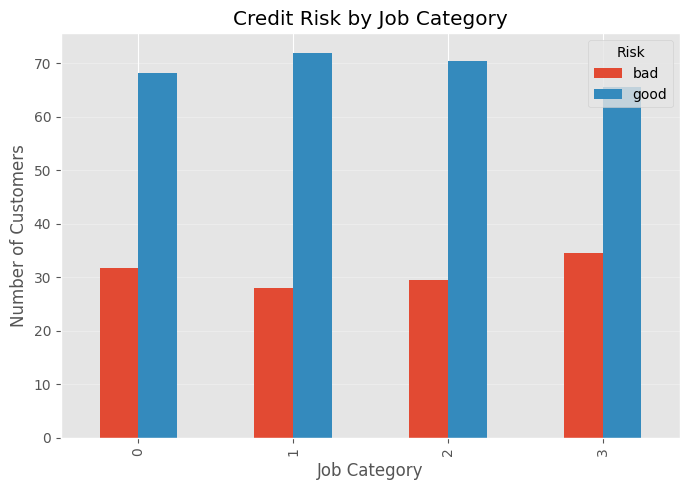

In [33]:
job_risk.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Credit Risk by Job Category")
plt.xlabel("Job Category")
plt.ylabel("Number of Customers")

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

### Key Findings

- Customers in **Job Category 1** have the lowest proportion of **Bad** credit risk (**28.00%**) and the highest proportion of **Good** credit risk (**72.00%**).
- Customers in **Job Category 3** have the highest proportion of **Bad** credit risk (**34.46%**).
- Job Categories **0** and **2** have similar credit risk distributions, with approximately 30% of customers classified as **Bad** credit risks.
- The differences in bad credit risk across job categories are relatively small compared to some other variables such as Housing and Loan Purpose.

### Business Interpretation

The analysis suggests that job category has some relationship with credit risk, although the differences between categories are less pronounced than those observed for housing status or loan purpose.

Job category may still contribute useful predictive information when combined with other customer characteristics. Therefore, it will be retained as a feature during machine learning model development and evaluated alongside the other predictors.

**Age vs Risk**

<Figure size 800x500 with 0 Axes>

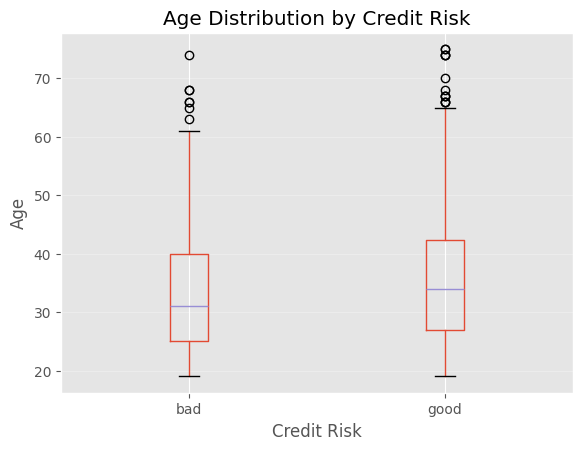

In [34]:
plt.figure(figsize=(8,5))

df.boxplot(column="Age", by="Risk")

plt.title("Age Distribution by Credit Risk")
plt.suptitle("")  # Removes the automatic title
plt.xlabel("Credit Risk")
plt.ylabel("Age")

plt.grid(axis='y', alpha=0.3)
plt.show();

### Key Findings

- Customers classified as **Good** credit risk have a slightly higher median age than those classified as **Bad** credit risk.
- The age distributions of the two groups overlap considerably, indicating that both younger and older customers are present in each risk category.
- Both groups contain several older-age outliers, with applicants aged above 65 years.

### Business Interpretation

The results suggest that age may have some relationship with credit risk, with older applicants appearing slightly more likely to be classified as **Good** credit risks. However, the substantial overlap between the two distributions indicates that age alone is not a strong predictor of credit risk.

During model development, **Age** will be evaluated together with other variables such as loan amount, loan duration, housing status, and account information to improve prediction accuracy.

**Credit Amount vs Risk**

<Figure size 800x500 with 0 Axes>

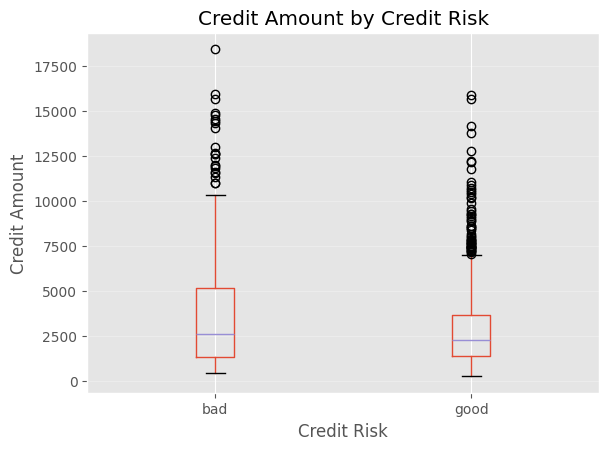

In [35]:
plt.figure(figsize=(8,5))

df.boxplot(column="Credit amount", by="Risk")

plt.title("Credit Amount by Credit Risk")
plt.suptitle("")
plt.xlabel("Credit Risk")
plt.ylabel("Credit Amount")

plt.grid(axis='y', alpha=0.3)
plt.show()

### Key Findings

- Customers classified as **Bad** credit risk have a slightly higher median loan amount than customers classified as **Good** credit risk.
- The distribution of loan amounts for bad credit risk customers is more dispersed, indicating greater variability in borrowing amounts.
- Both credit risk groups contain several high-value loan outliers, with some loans exceeding **15,000** monetary units.
- Although there is considerable overlap between the two groups, larger loan amounts appear to be more common among bad credit risk customers.

### Business Interpretation

The analysis suggests that customers requesting larger loans may have a slightly higher likelihood of being classified as **Bad** credit risks. This finding is consistent with the idea that larger loans expose lenders to greater financial risk if repayment problems occur.

However, the substantial overlap between the two groups indicates that **Credit Amount** alone is not sufficient for predicting credit risk. It should be evaluated together with other customer characteristics such as loan duration, housing status, savings, checking account status, and age in the machine learning model.

**Duration vs Risk**

<Figure size 800x500 with 0 Axes>

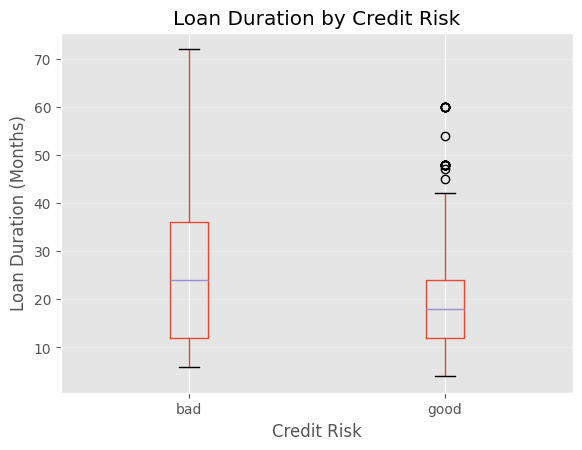

In [36]:
plt.figure(figsize=(8,5))

df.boxplot(column="Duration", by="Risk")

plt.title("Loan Duration by Credit Risk")
plt.suptitle("")
plt.xlabel("Credit Risk")
plt.ylabel("Loan Duration (Months)")

plt.grid(axis="y", alpha=0.3)
plt.show()

### Key Findings

- Customers classified as **Bad** credit risk have a noticeably higher median loan duration than customers classified as **Good** credit risk.
- The distribution of loan durations for bad credit risk customers is wider, indicating greater variability in repayment periods.
- Longer loan durations are more common among customers classified as bad credit risks.
- Although the two groups overlap, loan duration appears to distinguish credit risk better than age or credit amount.

### Business Interpretation

Loan duration appears to be one of the strongest predictors of credit risk in this dataset. Customers with longer repayment periods are more frequently classified as **Bad** credit risks.

Long-term loans expose lenders to greater uncertainty because borrowers are more likely to experience changes in employment, income, interest rates, or economic conditions over an extended repayment period.

These findings suggest that **Duration** is likely to be an important feature in the machine learning model and may contribute significantly to predicting credit risk.

**Saving Accounts vs Risk**

In [37]:
pd.crosstab(
    df["Saving accounts"],
    df["Risk"],
    normalize="index"
) * 100

Risk,bad,good
Saving accounts,,
little,35.986733,64.013267
moderate,33.009709,66.990291
quite rich,17.460317,82.539683
rich,12.500000,87.500000


### Key Findings

- Customers with **Rich** saving accounts have the lowest proportion of **Bad** credit risk (**12.50%**) and the highest proportion of **Good** credit risk (**87.50%**).
- Customers with **Quite Rich** saving accounts also have a high proportion of **Good** credit risk (**82.54%**).
- Customers with **Little** saving accounts have the highest proportion of **Bad** credit risk (**35.99%**).
- As the level of savings increases, the proportion of bad credit risk decreases.

### Business Interpretation

Saving account status appears to be a strong indicator of creditworthiness. Customers with higher savings are more likely to be classified as **Good** credit risks, while customers with lower savings exhibit higher proportions of **Bad** credit risk.

This relationship is consistent with financial risk management principles, as customers with greater savings may have stronger financial resilience and a greater ability to meet their loan repayment obligations.

The findings suggest that **Saving Account** is likely to be an important predictive feature and should be retained in the machine learning model.

**Checking Account vs Risk**

In [38]:
pd.crosstab(
    df["Checking account"],
    df["Risk"],
    normalize="index"
) * 100

Risk,bad,good
Checking account,,
little,49.270073,50.729927
moderate,39.033457,60.966543
rich,22.222222,77.777778


### Key Findings

- Customers with **Little** checking account balances have the highest proportion of **Bad** credit risk (**49.27%**).
- Customers with **Moderate** checking account balances have a lower proportion of **Bad** credit risk (**39.03%**).
- Customers with **Rich** checking account balances have the lowest proportion of **Bad** credit risk (**22.22%**) and the highest proportion of **Good** credit risk (**77.78%**).
- The proportion of bad credit risk decreases as checking account balance increases.

### Business Interpretation

Checking account status appears to be one of the strongest indicators of creditworthiness in this dataset. Customers with larger checking account balances generally exhibit better repayment performance and are more frequently classified as **Good** credit risks.

This finding aligns with banking practices, as customers with stronger liquidity are often better positioned to meet their loan obligations. The results suggest that **Checking Account** is likely to be a highly informative feature for predicting credit risk and should be retained during model development.

**5.3 Correlation Analysis**

In [39]:
correlation = df.select_dtypes(include=["int64","float64"]).corr()

correlation

,Age,Job,Credit amount,Duration
Age,1.000000,0.015673,0.032716,-0.036136
Job,0.015673,1.000000,0.285385,0.210910
Credit amount,0.032716,0.285385,1.000000,0.624984
Duration,-0.036136,0.210910,0.624984,1.000000


**Visualize the Correlation Matrix**

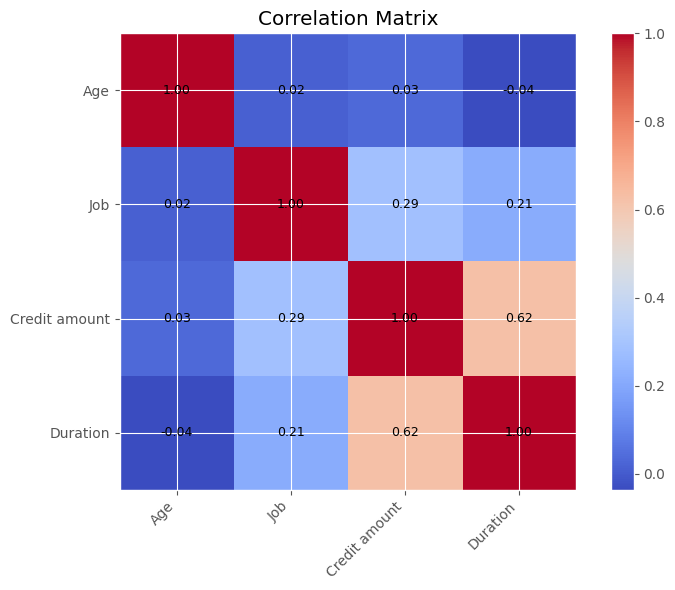

In [40]:
import matplotlib.pyplot as plt

correlation = df.select_dtypes(include=["int64","float64"]).corr()

fig, ax = plt.subplots(figsize=(8,6))

im = ax.imshow(correlation, cmap="coolwarm")

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.columns)))

ax.set_xticklabels(correlation.columns, rotation=45, ha='right')
ax.set_yticklabels(correlation.columns)

# Add correlation values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        ax.text(
            j,
            i,
            f"{correlation.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="black"
        )

plt.colorbar(im)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

## Correlation Analysis

### Key Findings

- Most numerical variables exhibit **weak to moderate correlations**, indicating that they capture different aspects of customer information.
- **Credit Amount** and **Loan Duration** show the strongest positive correlation among the numerical variables.
- **Age** has weak correlations with the other numerical variables.
- No strong negative correlations are observed.
- There is no evidence of severe multicollinearity among the numerical features.

### Business Interpretation

The correlation analysis suggests that each numerical variable contributes unique information about loan applicants. This is beneficial for machine learning because highly correlated variables can introduce redundancy and reduce model interpretability.

The positive relationship between **Credit Amount** and **Loan Duration** indicates that customers requesting larger loans tend to receive longer repayment periods, which is consistent with common banking practices.

Overall, the numerical variables appear suitable for inclusion in the credit risk prediction model.

## 5.4 Outlier Detection

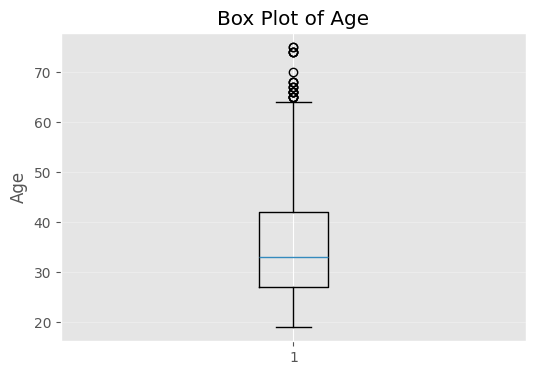

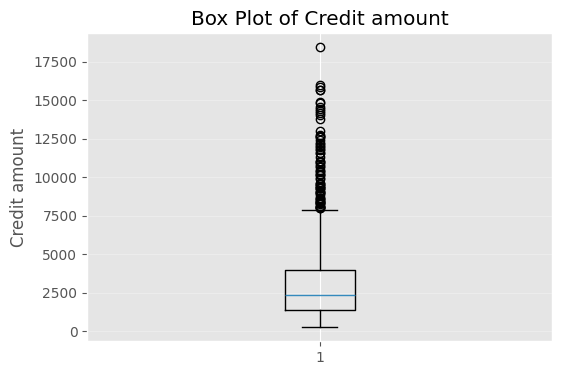

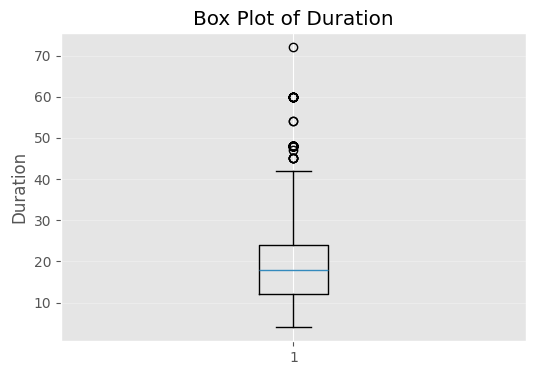

In [41]:
# Outlier Detection for Numerical Variables

numerical_columns = ["Age", "Credit amount", "Duration"]

for column in numerical_columns:

    plt.figure(figsize=(6,4))

    plt.boxplot(df[column])

    plt.title(f"Box Plot of {column}")

    plt.ylabel(column)

    plt.grid(axis="y", alpha=0.3)

    plt.show()

##  Outlier Detection

### Key Findings

- The **Age** variable contains a small number of outliers representing older applicants above approximately 65 years.
- The **Credit Amount** variable contains several high-value loan outliers, indicating that a small number of customers requested substantially larger loans than the majority.
- The **Duration** variable contains a few long-term loan outliers, with some loans extending beyond 60 months.
- These outliers appear to represent legitimate customer records rather than obvious data entry errors.

### Business Interpretation

Outliers are common in financial datasets because customer borrowing behavior naturally varies. Some customers qualify for larger loans, longer repayment periods, or belong to older age groups.

Since these observations likely reflect genuine lending cases, they will be retained during the initial stages of model development. Their impact on machine learning performance will be evaluated during preprocessing and model training, and appropriate techniques such as feature scaling or robust algorithms will be applied if necessary.